In [1]:
import sys
sys.path.append('../utils/')
from utils_models import *

In [41]:
max_ql = 20
max_ol = 80
EJ = 4
EC = EJ/2.7
EL = EJ/45
Er = 10.38695526

g = 0.2
w_d = 10.389507326769158
amp = 0.005

tot_time =1000
tlist = np.linspace(0, tot_time, tot_time)
system  =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g,
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in range(15) for ol in range(max_ol) ],
                computaional_states = '0,2',
                )

In [3]:
with open('sesolve_large_dim_a005.pkl', 'rb') as file:
    results = pickle.load(file)

(0.0, 470.0)

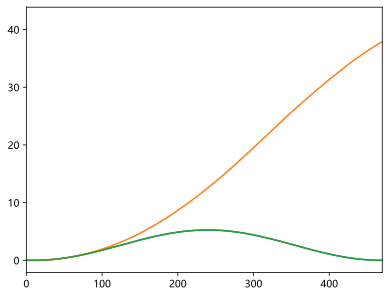

In [7]:
for i in [0,1,2]:
    plt.plot(results[i].expect[1])
plt.xlim(0,470)

(0.0, 0.01)

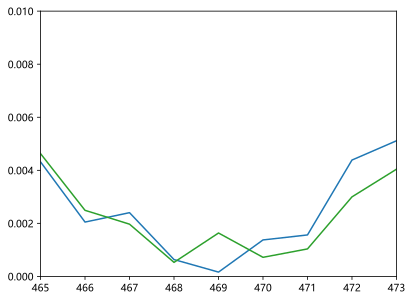

In [12]:
for i in [0,1,2]:
    plt.plot(results[i].expect[1])
plt.xlim(465,473)
plt.ylim(0,0.01)

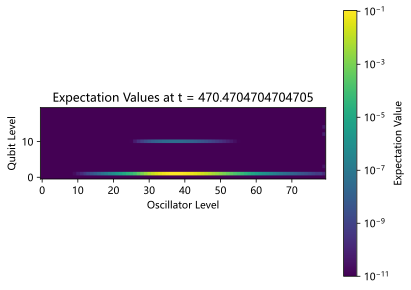

In [45]:
from utils_visualization import *
plot_heatmap(results[1],470,system.product_to_dressed,max_ql,max_ol,LogNorm())

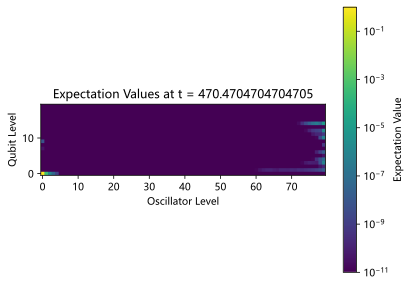

In [84]:
from utils_visualization import *
plot_heatmap(results[0],470,system.product_to_dressed,max_ql,max_ol,LogNorm())

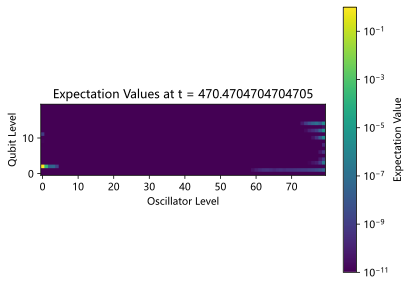

In [85]:
from utils_visualization import *
plot_heatmap(results[2],470,system.product_to_dressed,max_ql,max_ol,LogNorm())

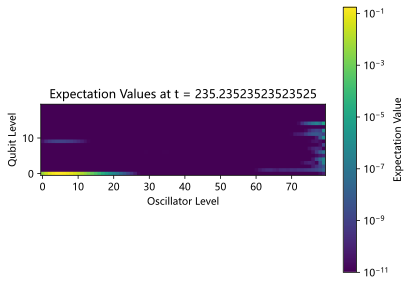

In [86]:
from utils_visualization import *
plot_heatmap(results[0],235,system.product_to_dressed,max_ql,max_ol,LogNorm())

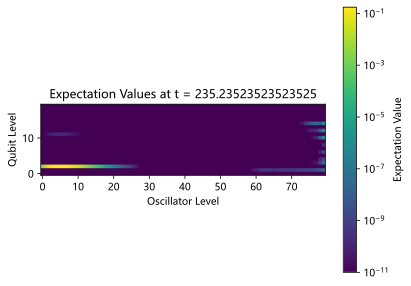

In [87]:
from utils_visualization import *
plot_heatmap(results[2],235,system.product_to_dressed,max_ql,max_ol,LogNorm())

In [46]:
lists = []
for ql in [0 ,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 1
        for q in range(15):
            if q == ql:
                for o in range(max_ol):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = system.truncate_function(qutip.basis(max_ql * max_ol,  dressed_state))
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum -= expectation_value

        pop_list.append(pop_sum)
    lists.append(pop_list)


t loop: 100%|██████████| 100/100 [01:06<00:00,  1.50it/s]


In [48]:
# with open('sesolve_large_dim_outside_ori_ladder_list_g0.2a005.pkl', 'wb') as file:
#     pickle.dump(lists, file)

Text(0.5, 0, 't (ns)')

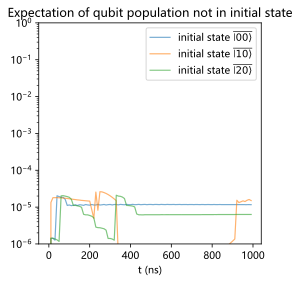

In [49]:
# from utils_models import *
plt.figure(figsize=(4,4))
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist[::10],pop_list,label = rf"initial state $\overline{{\left|{ql}0\right>}}$",linewidth =1.2,alpha = 0.6)
plt.yscale('log')
plt.ylim(1e-6,1)
plt.legend()
# plt.title('expecation of qubit not being in initial state,\n sesolve with 15 level qbt, 40 level osc')
plt.title('Expectation of qubit population not in initial state')
plt.xlabel('t (ns)')

In [52]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(15)]
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(15):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = system.truncate_function(qutip.basis(max_ql*max_ol, dressed_state))
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)


t loop: 100%|██████████| 100/100 [15:08<00:00,  9.09s/it]


In [53]:

# with open('sesolve_large_dim_pop_list_g0.2a005.pkl', 'wb') as file:
#     pickle.dump(lists, file)

In [3]:
with open('sesolve_large_dim_pop_list_g0.2a005.pkl', 'rb') as file:
    lists = pickle.load(file)
 

In [54]:
len(lists[0][0])

100

Text(0.5, 0, 't (ns)')

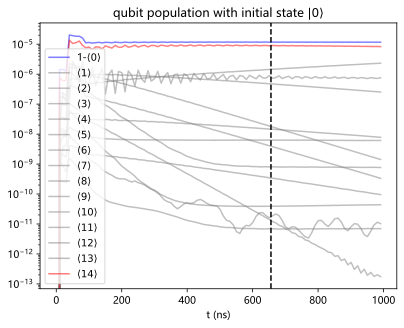

In [77]:
initial_ql = 0

qls = list(range(15))
for ql,pop_list in zip(qls,lists[initial_ql]): 
    if ql == initial_ql:
        plt.plot(tlist[::10],1-np.array(pop_list),label = rf"1-$\langle{ql}\rangle$",color='blue',alpha=0.5)
    elif ql != 14:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='grey',alpha=0.5)
    else:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='red',alpha=0.5)


plt.axvline(x=656, color='k', linestyle='--')

plt.title(rf'qubit population with initial state $|{initial_ql}\rangle$')
plt.yscale('log')
plt.legend()
plt.legend()
plt.xlabel('t (ns)')

Text(0.5, 0, 't (ns)')

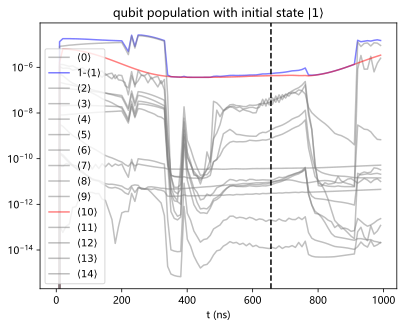

In [58]:
initial_ql = 1

qls = list(range(15))
for ql,pop_list in zip(qls,lists[initial_ql]): 
    if ql == initial_ql:
        plt.plot(tlist[::10],1-np.array(pop_list),label = rf"1-$\langle{ql}\rangle$",color='blue',alpha=0.5)
    elif ql != 10:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='grey',alpha=0.5)
    else:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='red',alpha=0.5)


plt.axvline(x=656, color='k', linestyle='--')

plt.title(rf'qubit population with initial state $|{initial_ql}\rangle$')
plt.yscale('log')
plt.legend()
plt.legend()
plt.xlabel('t (ns)')

Text(0.5, 0, 't (ns)')

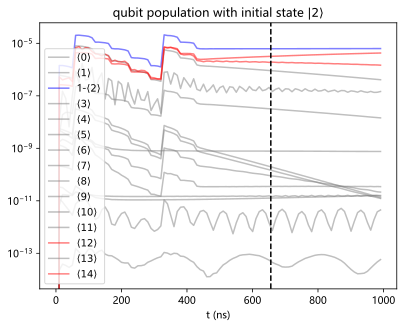

In [83]:
initial_ql = 2

qls = list(range(15))
for ql,pop_list in zip(qls,lists[initial_ql]): 
    if ql == initial_ql:
        plt.plot(tlist[::10],1-np.array(pop_list),label = rf"1-$\langle{ql}\rangle$",color='blue',alpha=0.5)
    elif ql not in [12,14]:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='grey',alpha=0.5)
    else:
        plt.plot(tlist[::10],pop_list,label = rf"$\langle{ql}\rangle$",color='red',alpha=0.5)


plt.axvline(x=656, color='k', linestyle='--')

plt.title(rf'qubit population with initial state $|{initial_ql}\rangle$')
plt.yscale('log')
plt.legend()
plt.legend()
plt.xlabel('t (ns)')

In [5]:
from utils_visualization import *

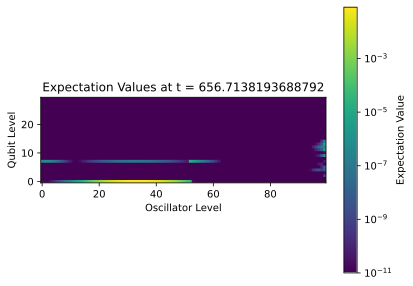

In [102]:
plot_heatmap(results[0],656, system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim,LogNorm())

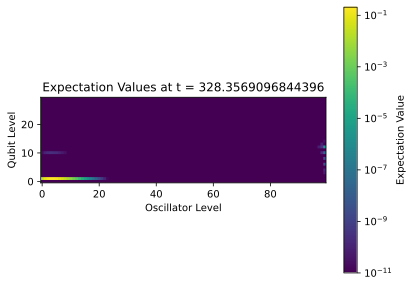

In [8]:
plot_heatmap(results[1],328, system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim,LogNorm())

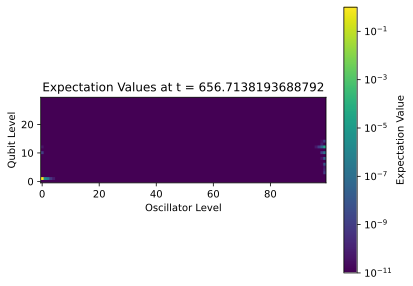

In [101]:
plot_heatmap(results[1],656, system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim,LogNorm())

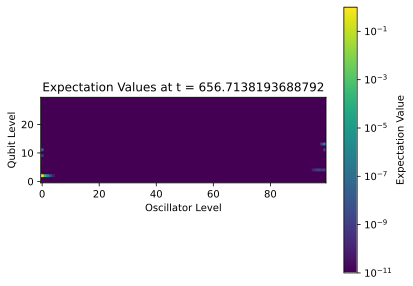

In [105]:
plot_heatmap(results[2],656, system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim,LogNorm())